In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pytz

from sklearn.metrics import r2_score

In [32]:
def preprocess_RAW(file_path):
    sensor = pd.read_csv(file_path, parse_dates=['timestamp'])
    sensor = sensor[['timestamp_local','rh','temp','o3']].dropna(subset=['o3'])
    sensor.rename(columns={'timestamp_local':'time'}, inplace=True)
    
    sensor['time'] = pd.to_datetime(sensor['time'])
    est = pytz.timezone('US/Eastern')
    sensor['time'] = sensor['time'].dt.tz_convert(est)
    sensor['time'] = sensor['time'].dt.strftime('%Y-%m-%d %H:%M:%S')
    sensor['time'] = pd.to_datetime(sensor['time'])
    sensor['day'] = sensor['time'].dt.date
    sensor['dayhour'] = sensor['time'].dt.strftime('%Y-%m-%d %H')

    sensor = sensor.groupby('dayhour').agg(
        o3=('o3', lambda x: x.mean(skipna=True)),
    ).reset_index()
    sensor = sensor.sort_values(by='dayhour')
    return sensor[['dayhour', 'o3']]

def preprocess_PRED(file_path):
    pred = pd.read_csv(file_path)
    pred = pred[['dayhour','corrected_O3h']].dropna(subset=['corrected_O3h'])
    pred.rename(columns={'corrected_O3h':'o3'}, inplace=True)

    pred = pred.sort_values('dayhour')
    return pred[['dayhour', 'o3']]

def preprocess_GAPA(file_path):
    gapa = pd.read_csv('CO&O3.csv', header=2)
    gapa.columns = ['Date', 'O3', 'CO']
    gapa = gapa[['Date', 'O3']]

    gapa['time'] = pd.to_datetime(gapa['Date'], format='%m/%d/%Y %H:%M')
    gapa['day'] = gapa['time'].dt.date
    gapa['dayhour'] = gapa['time'].dt.strftime('%Y-%m-%d %H')
    gapa.rename(columns={'O3':'ro3'}, inplace=True)
    gapa['ro3'] = gapa['ro3'] * 1000
    gapa.dropna(subset=['ro3'], inplace=True)
    # gapa.fillna(np.nan, inplace=True)
    h_gapa = gapa.groupby('dayhour').agg(
        o3=('ro3', lambda x: x.mean(skipna=True)),
    ).reset_index()

    h_gapa = h_gapa.sort_values('dayhour')
    print(h_gapa['dayhour'].max())

    return h_gapa[['dayhour', 'o3']]



2025-07-13 23
0.6061777967251005


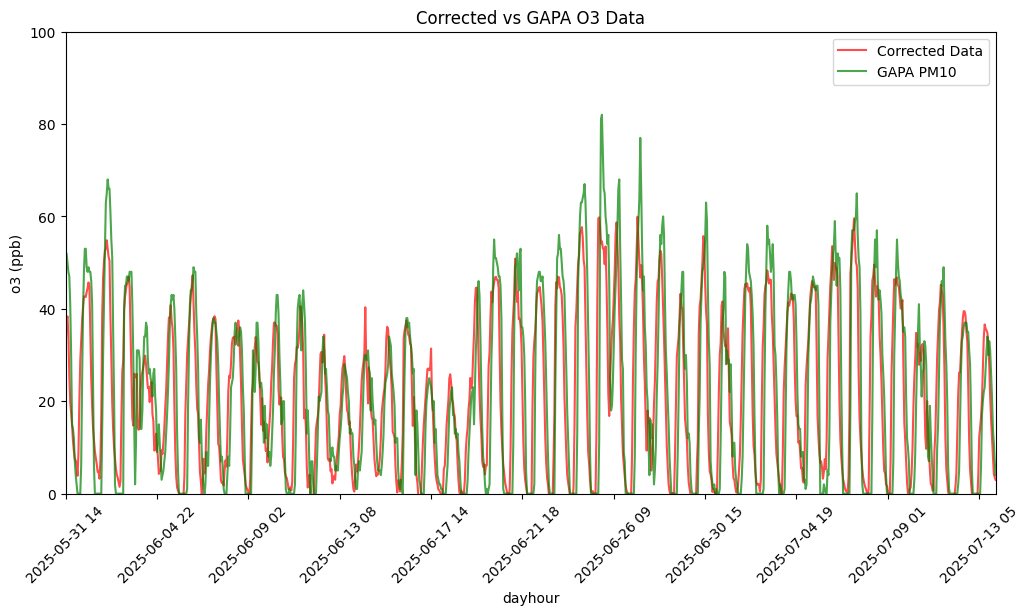

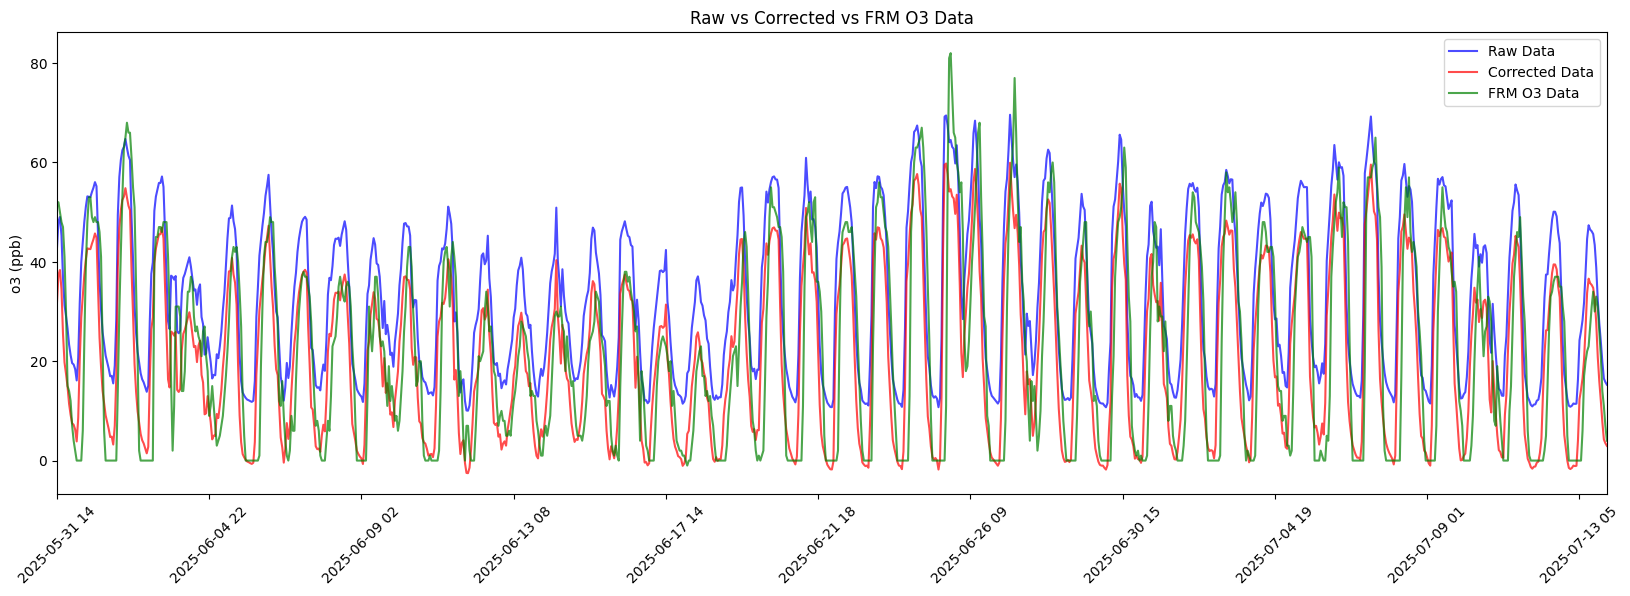

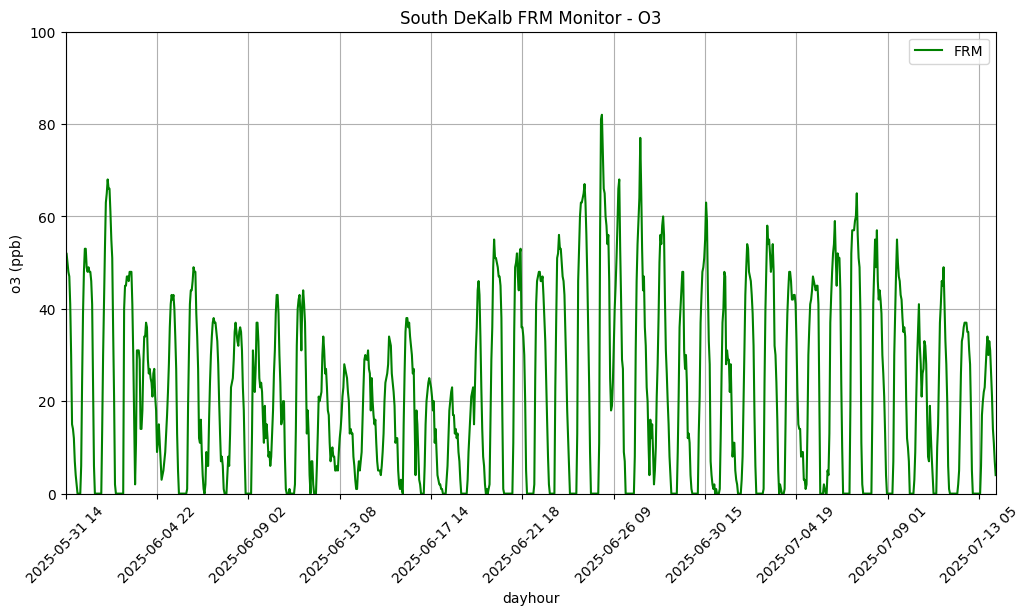

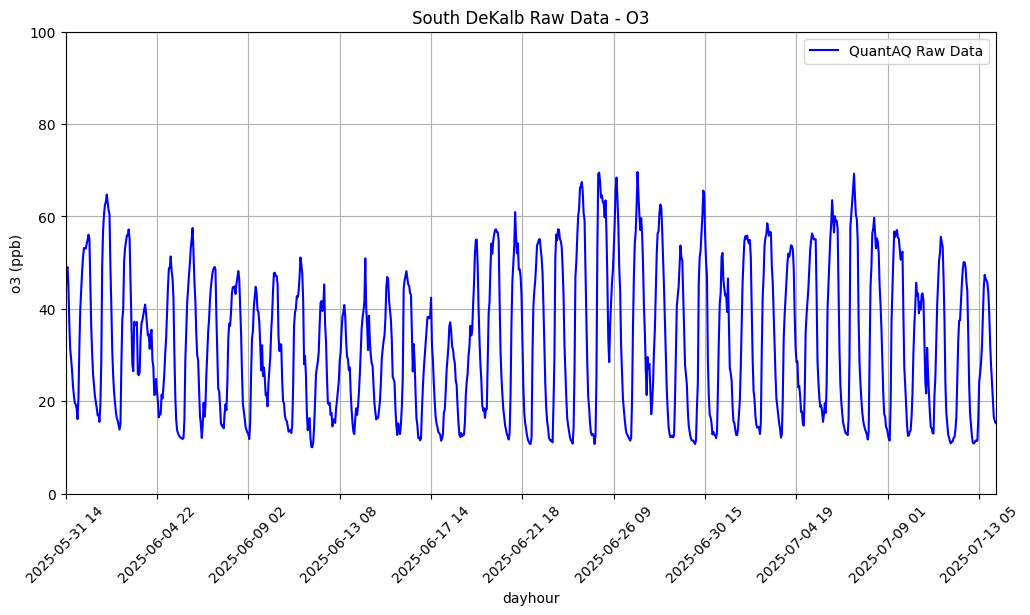

In [33]:
# create a figure with 3 subplots, raw, corrected, and GAPA
# fig, axs = plt.subplots(3, 1, figsize=(10, 15))
# axs[0].set_title('Raw Data')
# axs[1].set_title('Corrected Data')
# axs[2].set_title('GAPA Data')

# 1 plot with 3 lines


# read the data from csv files and preprocess
raw_data = preprocess_RAW('../ShortenedData/MOD-00592-RAW.csv')
corrected_data = preprocess_PRED('Predictions/hMOD-00592-PRED.csv')
# corrected_data = preprocess_PRED('hourly_model_predictions.csv')
gapa_data = preprocess_GAPA('CO&O3.csv')

# ensure all data have the same dayhour values
common_dayhours = set(raw_data['dayhour']).intersection(set(corrected_data['dayhour'])).intersection(set(gapa_data['dayhour']))
raw_data = raw_data[raw_data['dayhour'].isin(common_dayhours)]
corrected_data = corrected_data[corrected_data['dayhour'].isin(common_dayhours)]
gapa_data = gapa_data[gapa_data['dayhour'].isin(common_dayhours)]
r2 = r2_score(gapa_data['o3'], corrected_data['o3'])
print(r2)

# plot the data
plt.figure(figsize=(12, 6))
plt.plot(corrected_data['dayhour'], corrected_data['o3'], label='Corrected Data', color='red', alpha=0.7)
plt.plot(gapa_data['dayhour'], gapa_data['o3'], label='GAPA PM10', color='green', alpha=0.7)

# Add title and labels
plt.xlabel('dayhour')
plt.ylabel('o3 (ppb)')
plt.xticks(corrected_data['dayhour'][::100], rotation=45) # Show every 100th tick
plt.xlim(corrected_data['dayhour'].min(), corrected_data['dayhour'].max())
plt.ylim(0, 100)
plt.legend()
plt.title("Corrected vs GAPA O3 Data")
plt.show() # plot with no raw data

# plot including raw
plt.figure(figsize=(20, 6))
plt.ylabel('o3 (ppb)')
plt.plot(raw_data['dayhour'], raw_data['o3'], label='Raw Data', color='blue', alpha=0.7)
plt.plot(corrected_data['dayhour'], corrected_data['o3'], label='Corrected Data', color='red', alpha=0.7)
plt.plot(gapa_data['dayhour'], gapa_data['o3'], label='FRM O3 Data', color='green', alpha=0.7)
plt.xticks(corrected_data['dayhour'][::100], rotation=45) # Show every 100th tick
plt.xlim(corrected_data['dayhour'].min(), corrected_data['dayhour'].max())
plt.legend()
plt.title("Raw vs Corrected vs FRM O3 Data")
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(gapa_data['dayhour'], gapa_data['o3'], label='FRM', color='green')
plt.xlabel('dayhour')
plt.ylabel('o3 (ppb)')
plt.xticks(gapa_data['dayhour'][::100], rotation=45) # Show every 100th tick
plt.xlim(gapa_data['dayhour'].min(), corrected_data['dayhour'].max())
plt.ylim(0, 100)
plt.legend()
plt.title("South DeKalb FRM Monitor - O3")
plt.grid()
plt.show()


plt.figure(figsize=(12, 6))
plt.plot(raw_data['dayhour'], raw_data['o3'], label='QuantAQ Raw Data', color='blue')
plt.xlabel('dayhour')
plt.ylabel('o3 (ppb)')
plt.xticks(raw_data['dayhour'][::100], rotation=45) # Show every 100th tick
plt.xlim(raw_data['dayhour'].min(), corrected_data['dayhour'].max())
plt.ylim(0, 100)
plt.legend()
plt.title("South DeKalb Raw Data - O3")
plt.grid()
plt.show()
